# Analys av diamanter

## Innehållsförteckning

### 1. Bakgrund
### 2. Datakvalite
### 3. Analys
* 3.1 Inläsning av data och hantering av datakvalite
* 3.2 Korrelationer mellan pris och kvalitetsattribut  
* 3.3 Pris och kvalitetsattribut (cut, color, clarity)  
* 3.4 Regressionsplottar för ökad tydlighet  
* 3.5 Boxplots/Lådagram: för att identifiera koncentrationen av pris beroende på kvalitetsattribut  
* 3.6 Genomsnittspris per caratintervall  
* 3.7 Pris beroende på kvalitetsattribut  
* 3.8 Hitta extremvärden i priser per carat  
* 3.9 Genomsnittligt pris per carat per Caratintervall  
* 3.10 Diamanter med clarity IF, <0.25 carat, pris < $450  
* 3.11 Pris beroende på cut och color 0.25 carat  
* 3.12 Stenar som matchar kraven < 0.3 carat, IF, D, Excellent under 1000 dollar  
* 3.13 Avväjning av kvalite och djupare marknadsanalys  
* 3.14 Uppfattning om volatilitet  
* 3.15 Beräkna medianpris för diamanter inom caratintervaller  
* 3.16 Filtrera på diamanter vars pris är 10% under medianpriset  
* 3.17 Beräkning av potentiell avkastning   
### 4. Executive summary
### 5. Funktion för sökning av underprisade diamanter

## 1. Bakgrund

Följande datanalys avser läsas av guldfynds styrelse. 

Guldfynd överväger att utöka sortimentet med diamanter. Syftet med följande analys är att identifiera mönster och korrelationer för att kunna ge rekommendationer kring vilka diamanter som har högst potential för avkastning. Vi använder datasetet "diamonds.csv" innehållandes 50 000 observationer för att utföra vår analys. Nedan visas ett demo på datasetetes struktur och kolumner. 

**Nedan följer övergriplig information om diamanter och dess kvalitetsattribut:**

Kvaliteten på diamanter bedöms utifrån de så kallade 4C: Carat, Cut, Color och Clarity.

 - Carat mäter diamantens vikt. En carat är 0.2 gram.

- Cut beskriver hur väl diamanten är slipad och påverkar hur mycket den gnistrar. Kvalitetsnivåer: Excellent, Very Good, Good, Fair, Poor

- Color bedöms på en skala från D (färglös, högst kvalitet) till J (svag gul ton).

- Clarity visar hur ren en diamant är: från helt fri från fel (IF) till många synliga eller små märken. (I3) som du kan se med ögat.

Dessa faktorer påverkar både diamantens skönhet och värde.

## 2. Datakvalite

Som avslutande inleding vill jag även uppmärksamma brister i datakvaliten: 
1. Vissa värden i x, y, z kolumnerna innehåller inga värden/0/NAN. Utan dimensioner kan diamanten inte fysiskt existera. Dessa ska exkluderas i beräkningarna. Vi gör också en kontroll att dimensionerna överensstämmer med caraten: Carat ≈ (x * y * z) * 0.0061
2. Vissa värden är icke numeriska. För att utföra beräkningar och eventuellt i framtiden träna en modell på datan bör vi omvandla datan till numeriska. 
3. Blandade värden i cut kolumnen. Kan resultera i inkonsekventa resultat. Vi behöver omvandla värdena till ett enskilt klassificeringssystem. 

## 3. Analys

### 3.1 Inläsning av data

In [11]:
#Import av bibliotek
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

### 3.2 Korrelationer mellan pris och kvalitetsattribut och hantering av datakvalite

In [13]:
    # Vi hämtar filen och sparar den i variabeln "df"
    df = pd.read_csv("diamonds.csv")
    
    # Vi utesluter x, y och z värden som har null värden eller 0
    df = df[(df['x'] > 0) & (df['y'] > 0) & (df['z'] > 0)]
    df = df.dropna(subset=['x', 'y', 'z'])
    
    # Enligt datakvalite ovan skapar vi ett konsekvent kvalitesystem där vi gör om t.ex excelllent till ideal. 
    # Vi anänder skalan som finns i datasetet. 
cut_mapping = {
    'Ideal': 'Excellent',
    'Premium': 'Excellent',
    'Excellent': 'Excellent',
    'Very Good': 'Very Good',
    'Good': 'Good',
    'Fair': 'Fair',
    'Poor': 'Fair',
    'Shallow': 'Very Good',
    'Deep': 'Good',
    'Very Shallow': 'Fair',
    'Very Deep': 'Fair',
    'UNKNOWN': 'Fair'
}
    
    
    df["cut"] = df["cut"].astype(str).replace(cut_mapping)
    
    # Vi gör om df så att den innehåller ändringen av kvalitesystemet
    valid_cuts = ["Excellent", "Very Good", "Good", "Fair", "Poor"]
    df = df[df["cut"].isin(valid_cuts)]
    
    # Vi gör om ordningen så vi kan presentera datan mer förståeligt från sämst till bäst
    cut_order = ["Poor", "Fair", "Good", "Very Good", "Excellent"]
    df['cut'] = pd.Categorical(df["cut"], categories=cut_order, ordered=True)
    
    
    print("Unika värden i cut:\n", df['cut'].value_counts(dropna=False))
    
    df = df.dropna(subset=['x', 'y', 'z', 'carat'])
    
    # Beräkna uppskattad carat baserat på dimensionerna
    df['estimated_carat'] = df['x'] * df['y'] * df['z'] * 0.0061
    
    # 10% tolerans
    tolerance = 0.10
    df['carat_diff'] = abs(df['carat'] - df['estimated_carat']) / df['carat']
    
    # Filtrera bort extrema outliers (där skillnaden är större än toleransen)
    df = df[df['carat_diff'] <= tolerance]
    
    # (valfritt) Ta bort hjälpkolumnen om du inte vill ha den kvar
    df.drop(columns='carat_diff', inplace=True)
    
    df.head(5)

Unika värden i cut:
 cut
Excellent    35325
Very Good    12078
Good          4902
Fair          1609
Poor             0
Name: count, dtype: int64


,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z,estimated_carat
0,1,0.23,Excellent,E,SI2,61.5,55.0,326.0,3.95,3.98,2.43,0.233032
1,2,0.21,Excellent,E,SI1,59.8,61.0,326.0,3.89,3.84,2.31,0.210486
2,3,0.23,Good,E,VS1,56.9,65.0,327.0,4.05,4.07,2.31,0.232269
4,5,0.31,Good,J,SI2,63.3,58.0,335.0,4.34,4.35,2.75,0.316695
5,6,0.24,Very Good,J,VVS2,62.8,57.0,336.0,3.94,3.96,2.48,0.236033


Eftersom datasetet använder AGS för cut skalan har vi valt att göra om den till e n konsekvent skala. Eftersom datasetet inte innehåller ett enda värde av Poor eller Very deep tas dessa ej med i beräkning. Därför innehåller "Poor" ovan 0 i värde.

Vi börjar med att undersöka vilka variabler som påverkar priset mest. Enligt ovan har vi följande variabler att ta i beakt: carat, cut, color, clarity, depth, table, x, y, z. För att få en överblick av hur följande variabler påverkar priset kan vi skapa en korrelationsmatris. Korrelation visar hur starkt två variabler samverkar. Nedan följer 4 exempel: 

- +1 = positiv korrelation (när den ena ökar, ökar den andra exakt lika mycket)
- 0 = ingen korrelation
- -1 = Perfekt negativ korrelation (när den ena ökar, minskar den andra exakt lika mycket).
0.86 = Stark positiv korrelation/samband men inte perfekt.

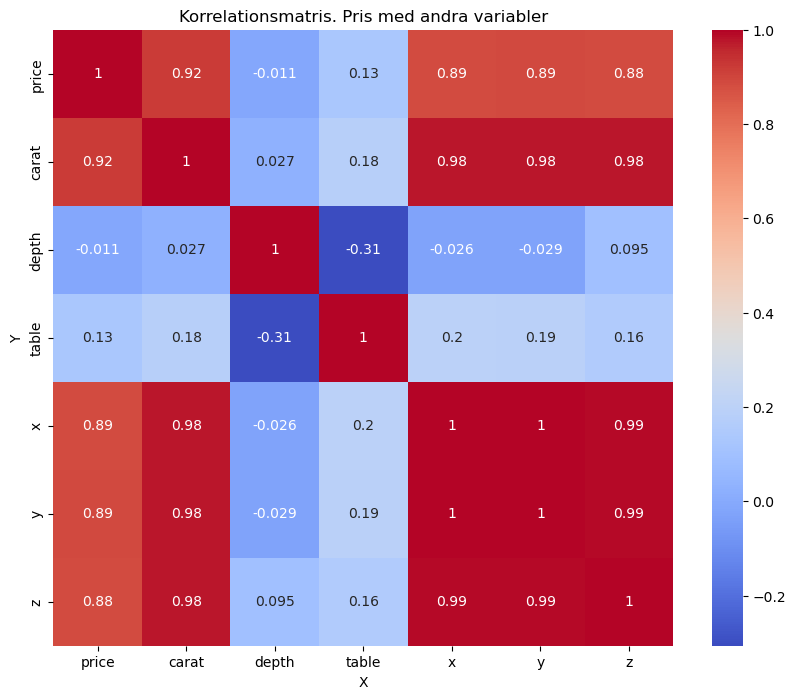

In [16]:
# Vi skapar en figur med figsize 10,8
plt.figure(figsize=(10,8))

#En heatmap med följande kolumnet:
sns.heatmap(df[["price", "carat", "depth", "table", "x", "y", "z"]].corr(), annot=True, cmap="coolwarm")

#Artists
plt.title("Korrelationsmatris. Pris med andra variabler")
plt.xlabel("X")  
plt.ylabel("Y")  
plt.show()

**Vad vi ser:**

När vi tittar på x-axelns pris och y-axelns pris ser vi uppenbarligen en perfekt korrelation när priset stiger, stiger priset. Låt oss titta på några fler variabler.

**Detta innebär följande:**

I det nedre vänstra hörnet ser vi att variablerna x, y och z har en relativt stark korrelation med priset. Utifrån detta kan vi dra slutsatsen att diamanterna blir dyrare ju större de är, eftersom x, y och z representerar stenens dimensioner. Carat, som mäter stenens vikt, har också ett tydligt samband med dimensionerna.

Vi ser även att carat har en mycket stark påverkan på priset, med ett korrelationsvärde på 0,92 är sambandet nästan perfekt. Det innebär att när carat ökar, ökar priset i nästan samma takt.

**Ur ett affärsperspektiv:**

Variabler med mycket låg korrelation, som till exempel depth i förhållande till carat, har nästan ingen koppling alls. Detta tyder på att vissa variabler, särskilt de blåfärgade rutorna med låga korrelationstal, kanske kan ignoreras vid vidare analys.

### 3.3 Pris och kvalitetsattribut (Cut, color, clarity)

Vidare undersökning av cut, color och clarity

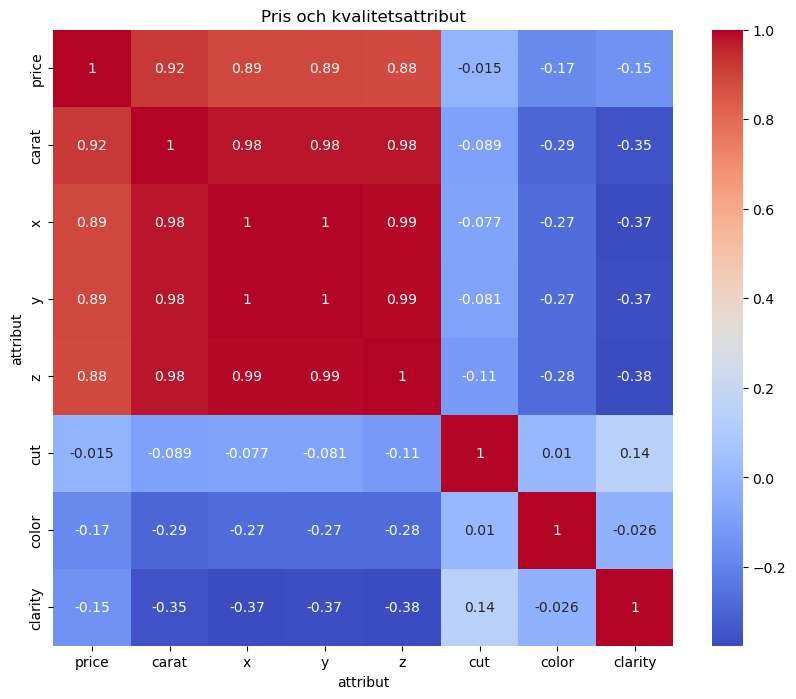

In [20]:
#Vi skapar en kopia av df för att inte manipulera originalet. 
df_corr = df.copy()

# Ordningen av data
cut_order = ["Poor", "Fair", "Good", "Very Good", "Excellent"]
color_order = ["J", "I", "H", "G", "F", "E", "D"]
clarity_order = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]

# Numeriska värden: t.ex poor = 0
df_corr["cut"] = df_corr["cut"].astype('category').cat.set_categories(cut_order, ordered=True).cat.codes
df_corr["color"] = df_corr["color"].astype('category').cat.set_categories(color_order, ordered=True).cat.codes
df_corr["clarity"] = df_corr['clarity'].astype('category').cat.set_categories(clarity_order, ordered=True).cat.codes

# Dessa kolumner använder vi i heatmapen nedan.
columns = ["price", "carat", "x", "y", "z", "cut", "color", "clarity"]

# värmekarta
plt.figure(figsize=(10, 8))
sns.heatmap(df_corr[columns].corr(), annot=True, cmap="coolwarm")

#Artists
plt.title("Pris och kvalitetsattribut")
plt.xlabel("attribut")
plt.ylabel("attribut")
plt.show()

**Vad vi ser:**

Det vi kan observera är att varken clarity, color eller cut tycks ha någon direkt tydlig korrelation med priset. 

**Detta innebär följande:**

Sambandet är mycket svagt, vilket tyder på att dessa kvalitativa egenskaper har en betydligt mindre påverkan på priset jämfört med exempelvis carat eller stenens dimensioner.

**Ur ett affärsperspektiv:**

Mer analys krävs men frågan väcks om dessa attribut är värda att ta hänsyn till. 

### 3.4 Regressionsplottar för ökad tydlighet

Regressionsplottar för att på ett annat vis visuellt representera hur stenens attribut påverkar priset

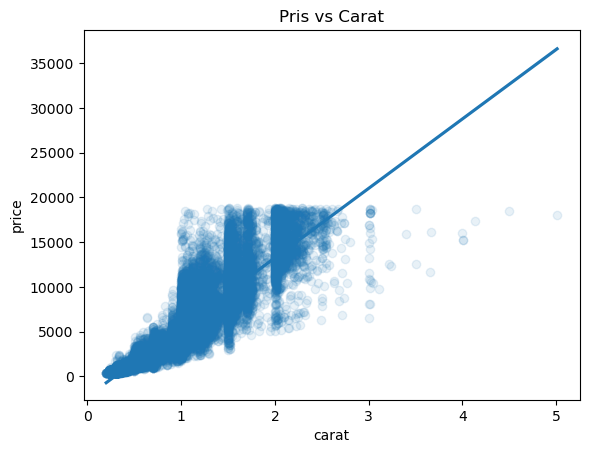

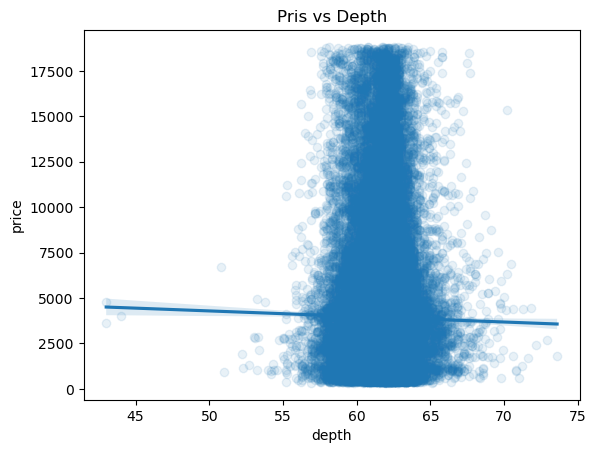

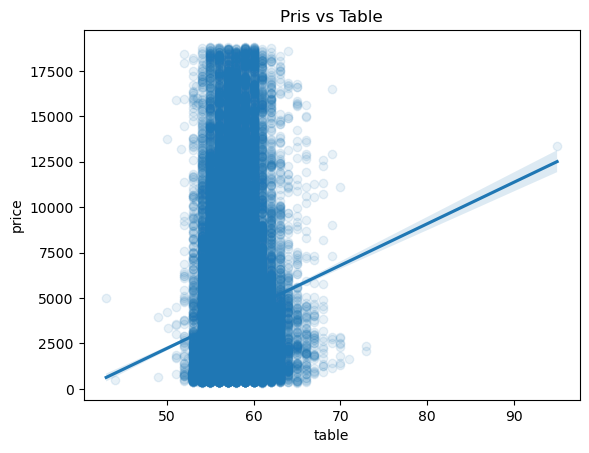

In [24]:
# Pris vs Carat

#En tom figure
fig, ax = plt.subplots()


sns.regplot(data=df, x="carat", y="price", scatter_kws={"alpha": 0.1}, ax=ax)
ax.set_title("Pris vs Carat")
plt.show()

# Pris vs D´depth
fig, ax = plt.subplots()
sns.regplot(data=df, x="depth", y="price", scatter_kws={"alpha": 0.1}, ax=ax)
ax.set_title("Pris vs Depth")
plt.show()

# Pris vs table
fig, ax = plt.subplots()
sns.regplot(data=df, x="table", y="price", scatter_kws={"alpha": 0.1}, ax=ax)
ax.set_title("Pris vs Table")
plt.show()

**Vad vi ser:**

Här använder vi regressionsplottar för att analysera korrelationen mellan numeriska variabler och pris. Det är tydligt att table och depth är koncentrerade kring vissa värden längs x-axeln. Detta innebär att diamanter med samma table eller depthvärde kan ha helt olika priser, vilket tyder på att dessa variabler i sig inte har någon direkt påverkan på priset.

**Detta innebär följande:**

Eftersom samma table eller depth kan motsvara helt skilda priser går det inte att dra några direkta slutsatser om deras påverkan. Det är däremot möjligt att dessa variabler samverkar med andra faktorer som i sin tur påverkar priset. I motsats till detta ser vi högst upp i plottarna att carat har en tydlig positiv korrelation med pris, en indikator på att vikt är en avgörande faktor vid prissättning.

**Ur ett affärsperspektiv:**

Fortsättningsvis kan vi även titta på de icke-numeriska variablerna för att undersöka hur priset varierar i kombination med exempelvis color, cut och clarity. Se nedan för en vidare analys.

### 3.5 Boxplots/Lådagram: för att identifiera koncentrationen av pris beroende på kvalitetsattribut

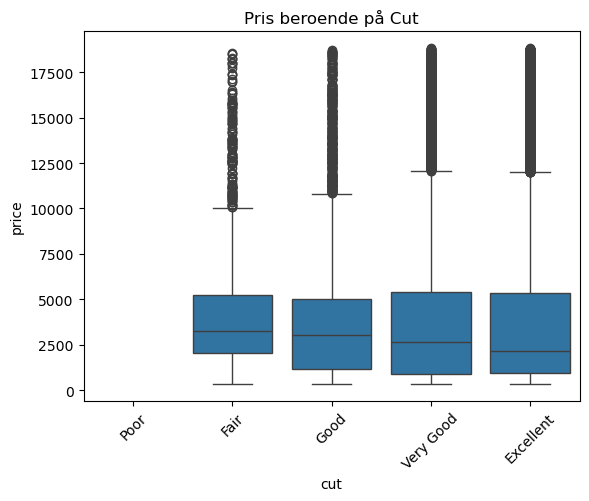

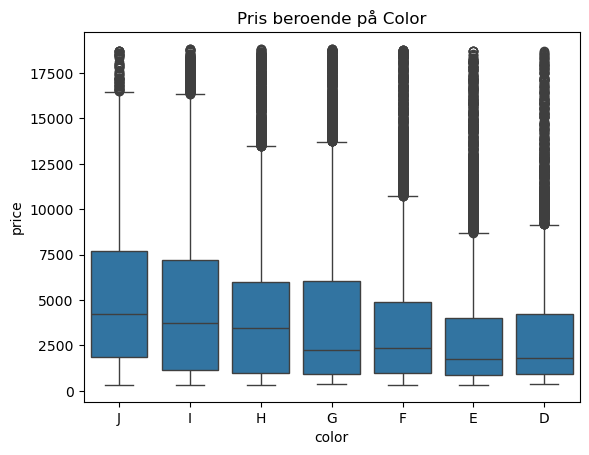

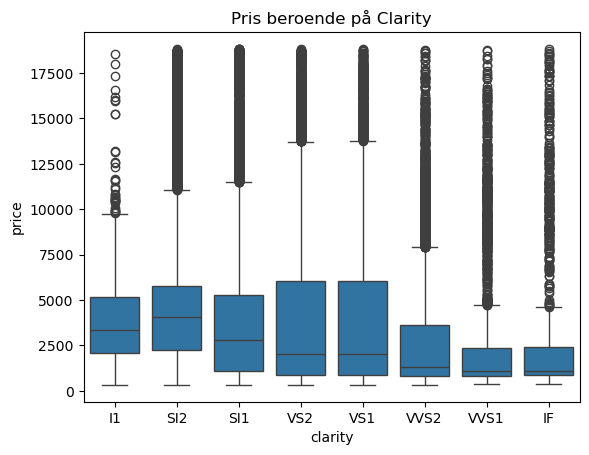

In [27]:
# Boxplot för cut
cut_order = ["Poor", "Fair", "Good", "Very Good", "Excellent"]
df['cut'] = pd.Categorical(df['cut'], categories=cut_order, ordered=True)

sns.boxplot(data=df, x="cut", y="price", order=cut_order)
plt.title("Pris beroende på Cut")
plt.xticks(rotation=45)
plt.show()

# Boxplot för  color
color_order = ["J", "I", "H", "G", "F", "E", "D"]
sns.boxplot(data=df, x="color", y="price", order=color_order)
plt.title("Pris beroende på Color")
plt.show()

# Boxplot för clarity
clarity_order = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]
sns.boxplot(data=df, x="clarity", y="price", order=clarity_order)
plt.title("Pris beroende på Clarity")
plt.show()

**Vad vi ser:**

Utifrån dessa tre lådagram ser vi att medianpriset för diamanter är relativt samlat, oavsett stenens klarhet (clarity), färg (color) eller slipning (cut). Det tyder på att de flesta priserna inom varje kategori är centrerade kring ett liknande värde.

**Detta innebär följande:**

Även om medianen är stabil, finns det en tydlig spridning i den övre kvartilen för samtliga variabler med vissa extremvärden. Det innebär att det finns utrymme för prisavvikelser uppåt inom varje kategori. Samtidigt visar variationen inom varje enskild grupp att dessa egenskaper i sig inte nödvändigtvis är de mest prispåverkande faktorerna.

**Ur ett affärsperspektiv:**

kan vi se att även stenar med lägre kvalitet i clarity kan ha ett högre genomsnittligt pris. Det kan bero på att diamanter med större carat-värde oftare har något sämre klarhet vilket kompenseras av deras storlek. Eftersom lådagrammen är ordnade efter kvalitet, ser vi tydligare detta mönster i "clarity".

Vi kommer att undersöka detta djupare i analysen: "Om diamantens clarity, color och cut bör tas i beaktande vid investering." En första slutsats är att dessa egenskaper troligen spelar roll. Inte nödvändigtvis på grund av sitt inflytande på priset, utan för att de påverkar kundupplevelse, marknadsföring och långsiktig försäljningspotential.

Nu när vi har identifierat att carat är den mest avgörande faktorn för priset, vill vi förstå vad genomsnittspriset är för varje viktklass.

Utifrån detta vill vi ta reda på pris per carat, vilket förhoppningsvis gör det möjligt att med hjälp av prediktiva modeller, i framtiden identifiera diamanter som är prissatta under sitt teoretiska marknadsvärde och därmed har hög potentiell avkastning.

Nedan tar vi reda på pris per carat. 

### 3.6 Genomsnittspris per caratintervall

/var/folders/66/n7t02x9n3px6n956yn182btr0000gn/T/ipykernel_15541/1720162828.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_carat_price = df.pivot_table(index='carat_range', values='price', aggfunc='mean')


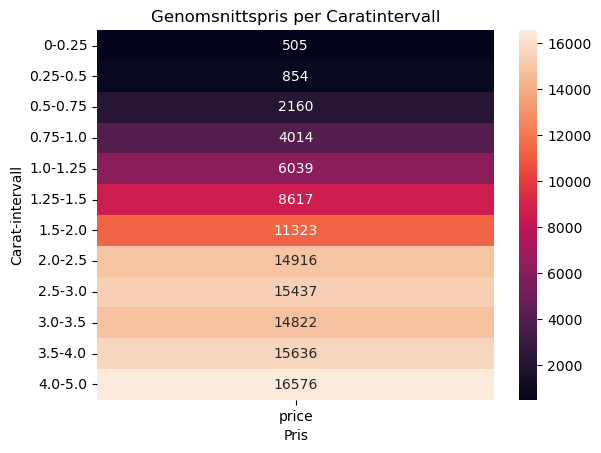

/var/folders/66/n7t02x9n3px6n956yn182btr0000gn/T/ipykernel_15541/1720162828.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_ppc = df.groupby('carat_range')['price_per_carat'].mean().reset_index()


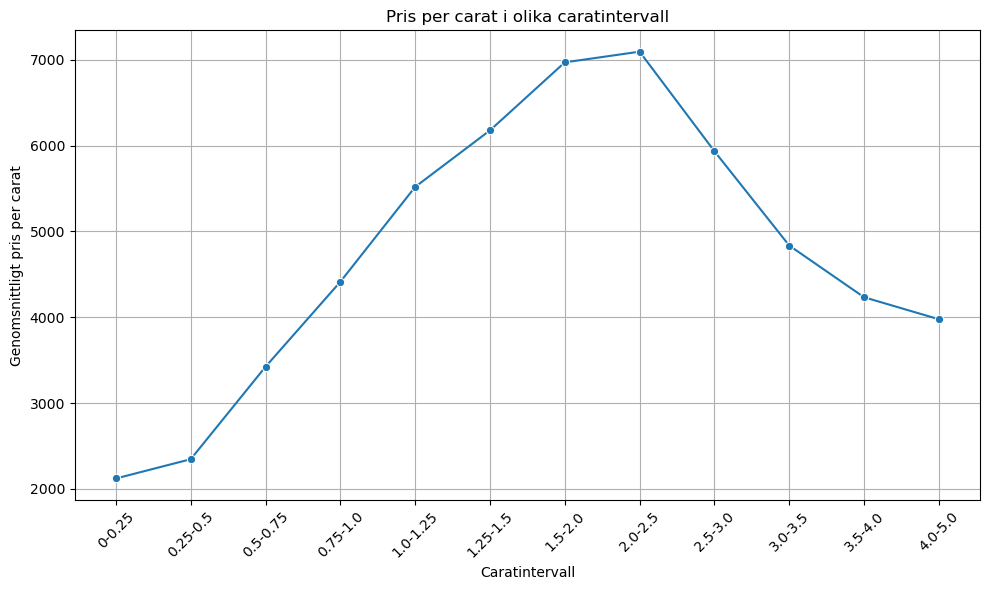

In [30]:
carat_intervals = [0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0]
labels = ["0-0.25", "0.25-0.5", "0.5-0.75", "0.75-1.0", "1.0-1.25", "1.25-1.5", 
          "1.5-2.0", "2.0-2.5", "2.5-3.0", "3.0-3.5", "3.5-4.0", "4.0-5.0"]

df["carat_range"] = pd.cut(df["carat"], bins=carat_intervals, labels=labels)

# pivot-tabell
pivot_carat_price = df.pivot_table(index='carat_range', values='price', aggfunc='mean')

# Skapa
sns.heatmap(pivot_carat_price, annot=True, fmt=".0f")
plt.title("Genomsnittspris per Caratintervall")
plt.xlabel("Pris")
plt.ylabel("Carat-intervall")
plt.show()



# Skapa caratintervall
bins = [0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0]
labels = ["0-0.25", "0.25-0.5", "0.5-0.75", "0.75-1.0", "1.0-1.25", "1.25-1.5", 
          "1.5-2.0", "2.0-2.5", "2.5-3.0", "3.0-3.5", "3.5-4.0", "4.0-5.0"]
df['carat_range'] = pd.cut(df['carat'], bins=bins, labels=labels)

# Räkna ut pris per carat
df['price_per_carat'] = df['price'] / df['carat']

# Genomsnittligt pris per carat per intervall
avg_ppc = df.groupby('carat_range')['price_per_carat'].mean().reset_index()

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=avg_ppc, x='carat_range', y='price_per_carat', marker='o')
plt.title('Pris per carat i olika caratintervall')
plt.xlabel('Caratintervall')
plt.ylabel('Genomsnittligt pris per carat')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

**Vad vi ser:**

Från denna visualisering ser vi genomsnittspriset för varje caratintervall i två olika format. Vi ser en tydlig uppgång runt 1.5-2.0.

**Detta innebär följande:**

Enbart utifrån heatmapen ovan hade vi redan kunnat fatta affärsmässiga beslut, till exempel att fokusera på försäljningspriser som ligger under genomsnittet inom ett visst intervall. Med stor sannolikhet hade det kunnat generera en god avkastning.

**Ur ett affärsperspektiv:**

Ur ett affärsperspektiv ser vi att kvalitetsegenskaper som cut, color och clarity förmodligen har en större påverkan på priset än vad vi först antog. Trots att detta inte går att visualisera isolerat verkar det som att kombinationen av dessa egenskaper spelar en avgörande roll i värderingen. Baserat på marknaden vi fokuserar på kan vi också förstå att det möjligtvis finns en hög efterfrågan och låg tillgång runt 1-5-2.0 carat. Mindre diamanter har hög tillgång och större diamanter är mindre attraktiva. 

### 3.7 Pris beroende på kvalitetsattribut

In [33]:
df["price_per_carat"] = df["price"] / df["carat"]
bottom10 = df[df["carat"] >= 1].sort_values("price_per_carat").head(10)
bottom10[["carat", "cut", "color", "clarity", "price_per_carat"]]
# BOTTOM 10

,carat,cut,color,clarity,price_per_carat
45505,1.00,Excellent,J,I1,1681.000000
46575,1.00,Fair,J,I1,1784.000000
46784,1.00,Fair,I,I1,1805.000000
48090,1.00,Excellent,H,I1,1932.000000
52422,1.30,Fair,H,I1,1932.307692
48259,1.00,Fair,G,I1,1954.000000
48884,1.04,Fair,I,I1,1958.653846
49217,1.06,Very Good,G,I1,1962.264151
51292,1.20,Excellent,F,I1,1966.666667
49141,1.05,Good,E,I1,1967.619048


In [34]:
# TOPP 10
top10 = df.sort_values("price_per_carat", ascending=False).head(10)
top10[["carat", "cut", "color", "clarity", "price_per_carat"]]

,carat,cut,color,clarity,price_per_carat
27635,1.04,Very Good,D,IF,17828.846154
27530,1.07,Excellent,D,IF,17083.177570
27226,1.03,Excellent,D,IF,17077.669903
27457,1.07,Very Good,D,IF,16928.971963
26998,1.02,Very Good,D,IF,16764.705882
27349,1.07,Very Good,D,IF,16737.383178
27507,1.09,Very Good,D,IF,16725.688073
26660,1.00,Excellent,D,IF,16469.000000
26549,1.01,Excellent,D,IF,16073.267327
26483,1.00,Very Good,D,IF,16073.000000


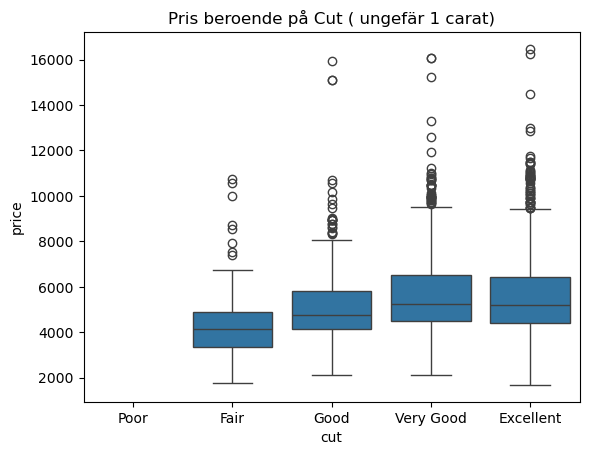

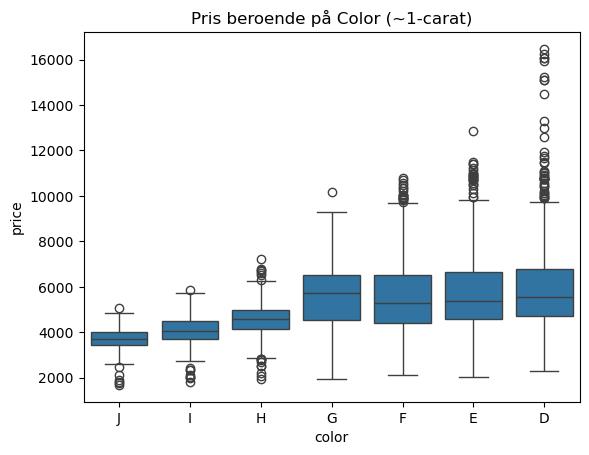

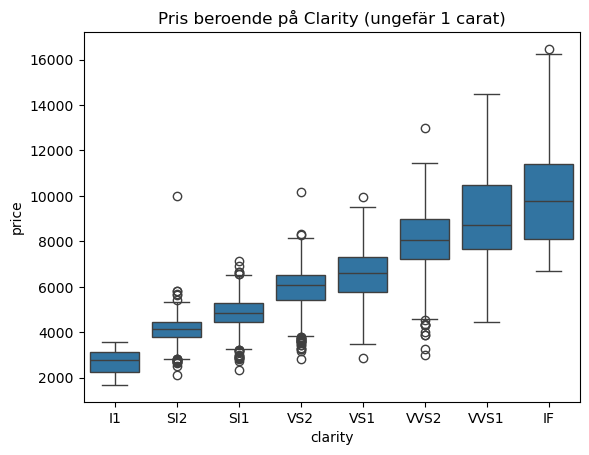

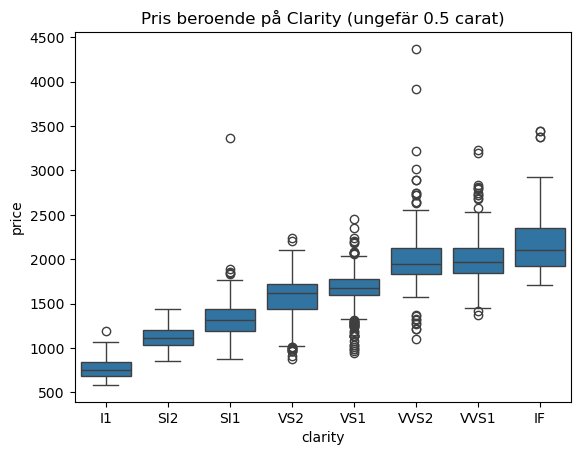

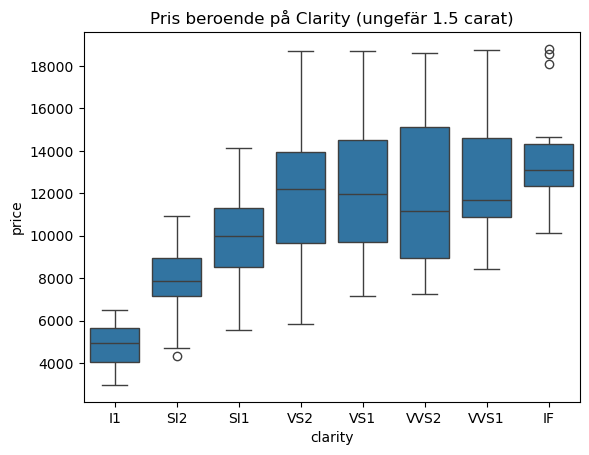

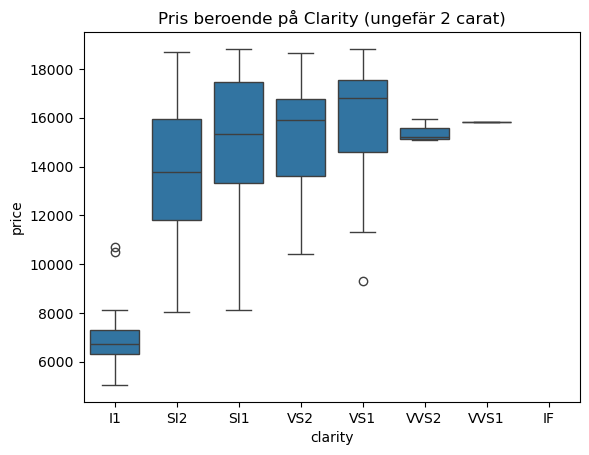

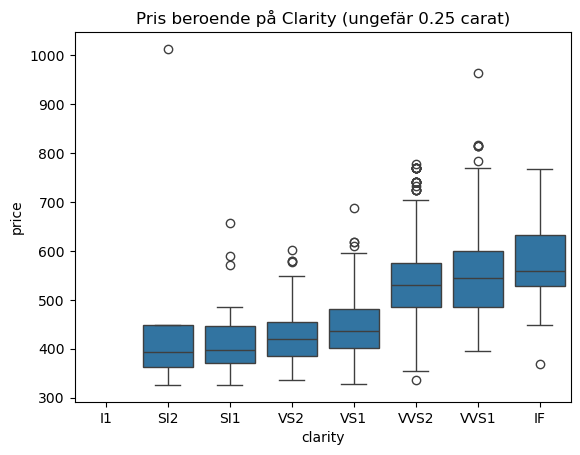

In [35]:
# order gör på sätt och vis om värdena till numeriska. Det är även inte nödvändigt i ett lådagram 
df_1carat = df[(df["carat"] >= 0.99) & (df["carat"] <= 1.01)]
df_2carat = df[(df["carat"] >= 0.49) & (df["carat"] <= 0.51)]
df_3carat = df[(df["carat"] >= 1.49) & (df["carat"] <= 1.51)]
df_4carat = df[(df["carat"] >= 1.99) & (df["carat"] <= 2.01)]
df_5carat = df[(df["carat"] >= 0.1) & (df["carat"] <= 0.26)]

cut_order = ["Poor", "Fair", "Good", "Very Good", "Excellent"]
sns.boxplot(data=df_1carat, x='cut', y='price', order=cut_order)
plt.title("Pris beroende på Cut ( ungefär 1 carat)")
plt.show()

color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
sns.boxplot(data=df_1carat, x='color', y='price', order=color_order)
plt.title("Pris beroende på Color (~1-carat)")
plt.show()

clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']
sns.boxplot(data=df_1carat, x='clarity', y='price', order=clarity_order)
plt.title("Pris beroende på Clarity (ungefär 1 carat)")
plt.show()

clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']
sns.boxplot(data=df_2carat, x='clarity', y='price', order=clarity_order)
plt.title("Pris beroende på Clarity (ungefär 0.5 carat)")
plt.show()

clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']
sns.boxplot(data=df_3carat, x='clarity', y='price', order=clarity_order)
plt.title("Pris beroende på Clarity (ungefär 1.5 carat)")
plt.show()

clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']
sns.boxplot(data=df_4carat, x='clarity', y='price', order=clarity_order)
plt.title("Pris beroende på Clarity (ungefär 2 carat)")
plt.show()

clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']
sns.boxplot(data=df_5carat, x='clarity', y='price', order=clarity_order)
plt.title("Pris beroende på Clarity (ungefär 0.25 carat)")
plt.show()

**Vad vi ser:**

Från denna visualisering ser vi att genom att isolera data till diamanter på ungefär 1 carat, kan vi tydligt urskilja ett samband mellan pris och clarity. I lådagrammet för clarity vid 1 carat framträder en klar korrelation där priset stiger med bättre clarity. Det är dock viktigt att komma ihåg att detta endast gäller för cirka 1 carat. Om vi i stället tittade på exempelvis 0.5 carat eller hela spannet från 0.1 till 5 carat, skulle diagrammet sannolikt se annorlunda ut. (Notera rubrikerna: Pris beroende på clarity vid 0.5, 1.5 och 2.0 carat.)

**Detta innebär följande:**

Även om det finns tydliga samband mellan pris och både cut och color, verkar clarity ha den största påverkan på priset när vi håller carat konstant. I samtliga tre intervaller börjar priset plana ut vid WS3, vilket är den tredje bästa clarity-nivån. Det kan tyda på att man får en betydligt högre kvalitet till samma pris om man fokuserar på just den nivån.


**Ur ett affärsperspektiv:**

ser vi att det vore värdefullt att undersöka detta vidare. Om det går att hitta finare stenar till samma eller lägre pris, kan det finnas en tydlig investeringsmöjlighet. Idén växer fram om att skapa en sorteringsfunktion i Streamlit som identifierar diamanter inom den lägre 25:e percentilen i pris, utifrån clarity, och samtidigt jämför detta med genomsnittspriset för respektive caratintervall.

### 3.8 Hitta extremvärden i priser per carat

Vi går tillbaka lite till grafen med genomsnittspris per carat men denna gången vill vi gräva djupare.

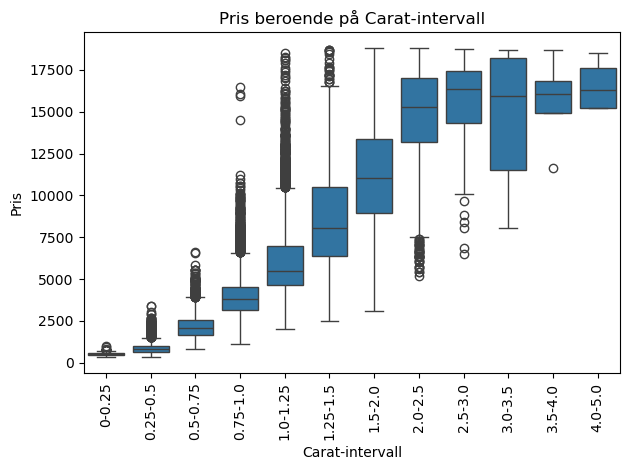

In [39]:
sns.boxplot(data=df, x='carat_range', y='price', order=labels)
plt.title("Pris beroende på Carat-intervall")
plt.xticks(rotation=90)
plt.xlabel("Carat-intervall")
plt.ylabel("Pris")
plt.tight_layout()
plt.show()

**Vad vi ser:**

Vi ser pris beroende på caratintervall. 
Vi vill ta reda på vilka carat intervaller som kan vara billigare.. För att göra detta behöver vi på något sätt beräkna medianen eller medelpriset för alla intervall. Detta ser vi resultatet av i lådagramet ovan. 

**Detta innebär följande:**

Målet är att hitta intervall där pris per carat är relativt lågt men totalpriset fortfarande är högt.

För att göra detta behöver vi beräkna det faktiska carat priset oavsett hur mycket stenen väger. Genom att ta reda på detta kan vi ta reda på om stenen generellt sett är billigare än andra stenar i andra carat intervaller. 

**Ur ett affärsperspektiv:**

Hittar vi billigare stenar per carat pris kan det indikera på goda investeringsmöjligheter. Se nedan.

### 3.9 Genomsnittligt pris per carat per Caratintervall

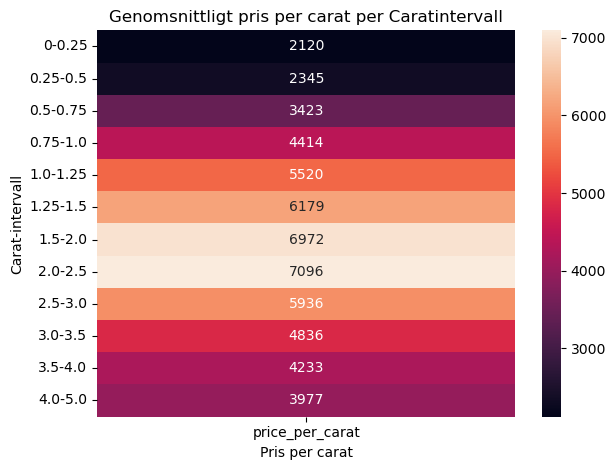

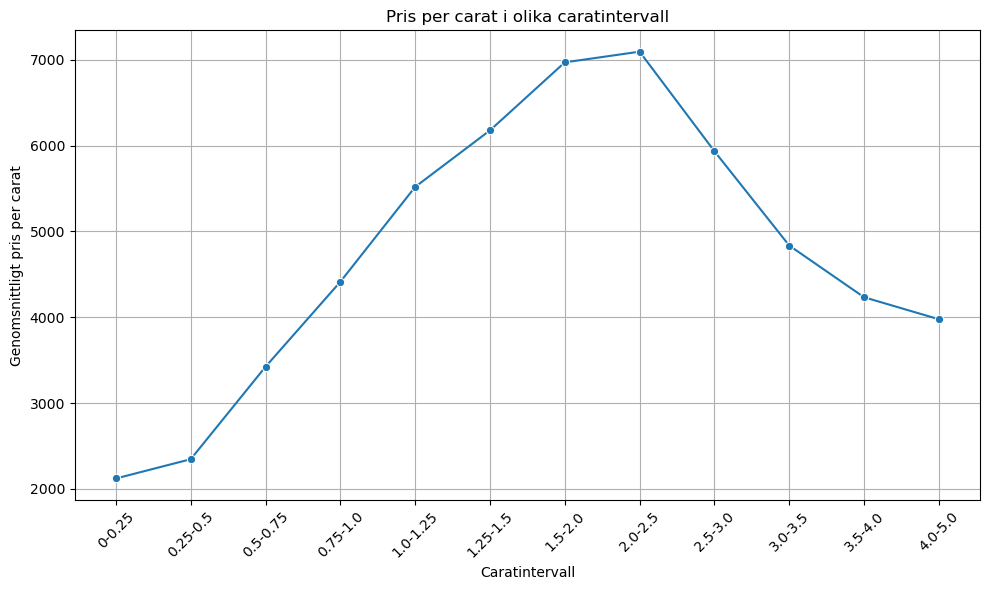

In [42]:



# caratintervall
bins = [0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0]
labels = ["0-0.25", "0.25-0.5", "0.5-0.75", "0.75-1.0", "1.0-1.25", "1.25-1.5", 
          "1.5-2.0", "2.0-2.5", "2.5-3.0", "3.0-3.5", "3.5-4.0", "4.0-5.0"]
df['carat_range'] = pd.cut(df['carat'], bins=bins, labels=labels)


df['price_per_carat'] = df['price'] / df['carat']


summarize_ppc = df.pivot_table(index="carat_range", values='price_per_carat', aggfunc='mean', observed=False)
summarize_total_price = df.pivot_table(index='carat_range', values='price', aggfunc='mean', observed=False)

# topp 3-analys
combined = summarize_ppc.join(summarize_total_price, rsuffix='total')
combined.columns = ['avg_price_per_carat', 'avg_total_price']
top3_value = combined.sort_values('avg_price_per_carat').head(3)

# Visa heatmap
sns.heatmap(summarize_ppc, annot=True, fmt=".0f")
plt.title("Genomsnittligt pris per carat per Caratintervall")
plt.xlabel("Pris per carat")
plt.ylabel("Carat-intervall")
plt.tight_layout()
plt.show()

top3_value

plt.figure(figsize=(10, 6))
sns.lineplot(data=avg_ppc, x='carat_range', y='price_per_carat', marker='o')
plt.title('Pris per carat i olika caratintervall')
plt.xlabel('Caratintervall')
plt.ylabel('Genomsnittligt pris per carat')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

**Vad vi ser:**

Från denna visualisering ser vi att priset per carat generellt är lägre när hela stenen väger mellan 0–0.25 carat. De absolut dyraste stenarna per carat återfinns i intervallet 2.0–2.5 carat. Detta beror troligen på en korrelation mellan tillgång och efterfrågan. Större diamanter, alltså över 1.0 carat, är mer sällsynta vilket leder till ett kraftigt prisuppsving. Samtidigt som de absolut största stenarna inte är lika efterfrågade därav är de billigare 

**Detta innebär följande:**

Priset stiger inte linjärt med caratvikten. Små diamanter är alltså betydligt billigare per carat än större stenar. Vi ser även att priset per carat ökar snabbt runt jämna viktgränser, troligen för att köpare värdesätter runda siffror som 1.0 eller 2.0 carat.

**Ur ett affärsperspektiv:**

Eftersom Guldfynds primära målgrupp är medelklassen, bör fokus riktas mer mot mindre diamanter snarare än större. Dessa erbjuder ofta bättre värde för pengarna och passar bättre inom kundernas budget vilket kan bidra till ökad försäljning och god avkastning. Nu när vi har indikationer på att de stenarna med carat 0.25 generellt är billigast sett till caratpriset vill vi kombinera detta med de billigaste stenarna med hög clarity. Vi kan leta efter stenar med hög clarity som ligger i den lägre procentilen i pris dvs typ 450 dollar för den högsta kvaliten.  

### 3.10 Diamanter med clarity IF, <0.25 carat, pris < $450

Vi filtrerar på stenar mellan 0 och 0.25 carat med clarity IF med ett pris under 450 dollar.

In [46]:
filtered = df[
    (df["carat"] > 0) & (df["carat"] <= 0.25) &
    (df["clarity"] == "IF") &
    (df["price"] < 450)
]

print(filtered[["carat", "clarity", "price"]])

       carat clarity  price
30942   0.24      IF  449.0
31610   0.23      IF  369.0


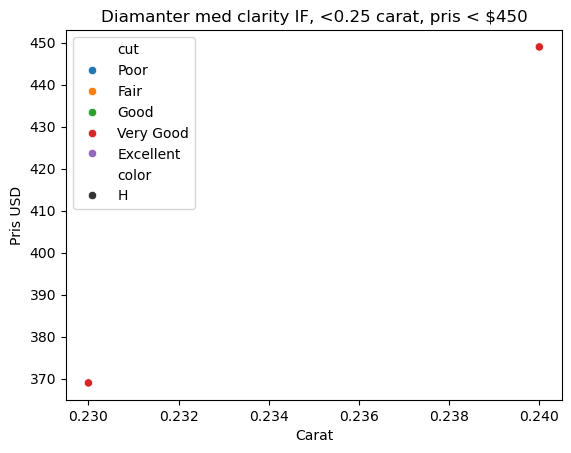

In [47]:
sns.scatterplot(data=filtered, x="carat", y="price", hue="cut", style="color")
plt.title("Diamanter med clarity IF, <0.25 carat, pris < $450")
plt.xlabel("Carat")
plt.ylabel("Pris USD")
plt.show()

**Vad vi ser:**

Okej, vi har inte jättemycket o gå på här nu mer än 2 resultat. Dessa två stenar skulle däremot potentiellt vara värda att investera i. Vi behöver släppa lite på filtreringen men vi ska nu också ta de andra kvalitetsattributen i beakt.

**Detta innebär följande:**

Nu när vi vill fokusera mer på de mindre stenarna bör vi ta en extra vända över de andra kvalitetesattributen som cut och color. Vi använder samma lådagram som ovan fast kikar på 0.25 carat istället för 1 carat.

**Ur ett affärsperspektiv:**

Vi försöker indentifiera billigare stenar men som bibehåller hög kvalite.

### 3.11 Pris beroende på cut och color 0.25 carat

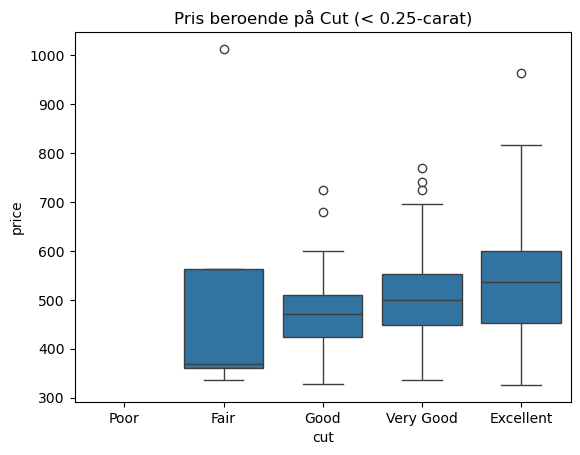

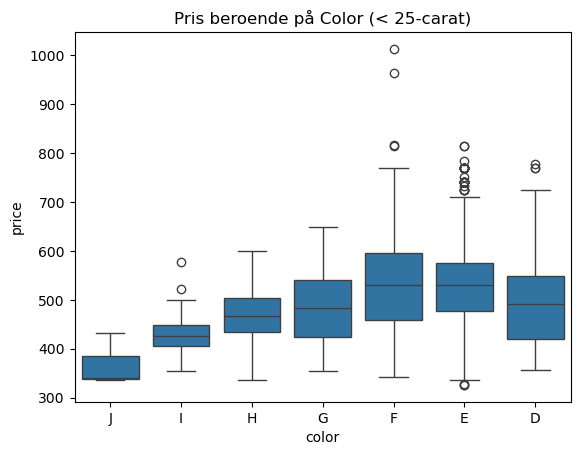

In [50]:
df_carat = df[(df["carat"] >= 0.1) & (df["carat"] <= 0.26)]

cut_order = ["Poor", "Fair", "Good", "Very Good", "Excellent"]
sns.boxplot(data=df_carat, x="cut", y="price", order=cut_order)
plt.title("Pris beroende på Cut (< 0.25-carat)")
plt.show()

color_order = ["J", "I", "H", "G", "F", "E", "D"]
sns.boxplot(data=df_carat, x="color", y="price", order=color_order)
plt.title("Pris beroende på Color (< 25-carat)")
plt.show()



**Vad vi ser:**

Vi kan se att kvaliten i cut inte verkar påverka priset särskilt mycket däremot är stenens color billigare desto bättre kvalite den har. Detta kan dock bero på att det finns väldigt få värden. Därför bör datan tas med en nypa salt. Vi kollar hur många stenar vi faktiskt får upp i denna filtreringen. 

**Detta innebär följande:**

Att vi vill ta reda på om det finns några som helst stenar som matchar samtliga krav, pris, carat, cut kvalite, color kvalite. 

**Ur ett affärsperspektiv:**

Vi försöker indentifiera billigare stenar men som bibehåller hög kvalite.



### 3.12 Stenar som matchar kraven < 0.3 carat, IF, D, Excellent under 1000 dollar

In [128]:
filtered = df[
    (df["carat"] <= 0.3) & 
    (df["clarity"] == 'IF') & 
    (df["color"] == 'D') & 
    (df["cut"] == 'Excellent') & 
    (df["price"] < 1000)
]
print("Antal matchande diamanter:", len(filtered))

Antal matchande diamanter: 1


In [130]:
filtered_with_index = filtered.reset_index()
filtered_with_index[["index", "carat", "clarity", "color", "cut", "price"]]

,index,carat,clarity,color,cut,price
0,35228,0.27,IF,D,Excellent,893.0


**Vad vi ser:**

Ovan har vi en sten i caratintervallet 0.25-0.3 i kombination med de bästa kvalitetsattributen. Priset hör till den övre procentilen i de flestas lådagram.

**Justering**

Ändrar vi kvalitetsattributet color från D till e får vi en lista på 9 nedan

In [135]:
filtered = df[
    (df["carat"] <= 0.3) & 
    (df["clarity"] == 'IF') & 
    (df["color"] == 'E') & 
    (df["cut"] == "Excellent") & 
    (df["price"] < 1000)
]

print("Antal matchande diamanter:", len(filtered))

Antal matchande diamanter: 9


In [57]:
filtered_with_index = filtered.reset_index()
filtered_with_index[["index", "carat", "clarity", "color", "cut", "price"]]

,index,carat,clarity,color,cut,price


**Vad vi ser:**

Från denna visualisering ser vi att om vi utgår från prisnivåerna i diamantkalkylatorer, så är de aktuella inköpspriserna inte konkurrenskraftiga. Om vi köper dessa stenar för över 800 dollar finns det stor risk att vi går med förlust.

**Detta innebär följande:**

Vi behöver göra en medveten avvägning gällande kvalitet för att sänka inköpspriset. För att uppnå lönsamhet krävs det att vi identifierar kompromisser som inte avsevärt försämrar produktens attraktivitet, men som reducerar kostnaden.

### 3.13 Avväjning av kvalite och djupare marknadsanalys

Vi undersöker marknaden för att se vad som faktiskt efterfrågas.

In [123]:
filtered = df[
    (df["carat"] <= 0.3) & 
    (df["clarity"] == 'IF') & 
    (df["price"] < 400)
]

print("Antal matchande diamanter:", len(filtered))

Antal matchande diamanter: 1


In [125]:
filtered_with_index = filtered.reset_index()
filtered_with_index[["index", "carat", "clarity", "color", "cut", "price"]]

,index,carat,clarity,color,cut,price
0,31610,0.23,IF,H,Very Good,369.0


**Vad vi ser:**

Här har vi en sten som ligger under det beräknade marknadspriset enligt denna sidan: https://www.stonealgo.com/diamond-price-calculator/calc?a=1&b=0.3&c=4&d=7&e=3&f=4&g=4&h=5&i=0

Från denna research kombinerat med tidigare visualiseringar ser vi att attributen color och clarity har en mindre påverkan på priset än förväntat. Många kunder kan till exempel inte urskilja skillnaden mellan färgskalorna D till G, vilket innebär att vi kan göra bättre affärer på G-diamanter. Även clarity-nivåerna VS1 och VS2 är visuellt nästan identiska men säljs till olika priser.

**Detta innebär följande:**

Genom att strategiskt välja stenar med något lägre color och clarity, men som fortfarande uppfattas som högkvalitativa, kan vi förbättra  våra marginaler utan att göra ett stort avkall på kvaliten.

Från affärsperspektiv ser vi att detta öppnar upp möjligheten att rikta in oss på segmentet:

Clarity: IF, VVS1

Color: E, F, G

Cut: Excellent

Carat: 0.25–0.30

Detta segment riktar sig främst till medelklassen, en målgrupp som enligt nordiska preferenser tenderar att uppskatta mindre men kvalitativa stenar. Det passar väl med Guldfynds marknadsposition. 

**Ur ett affärsperspektiv:**

Vi kommer därför att fokusera på diamanter under 1 carat och prioritera hög kvalitet där det visuella intrycket fortfarande uppfattas som högkvalitativt trots en något lägre kvalite på pappret.

Vi använder nu informationen ovan för att filtrera datan vidare.

In [65]:
filtered = df[
    (df["carat"] >= 0.25) & (df["carat"] <= 1) &
    (df["clarity"].isin(["IF", "VVS1"])) &
    (df["color"].isin(["E", "F", "G"])) &
    (df["cut"] == "Excellent") &
    (df["price"] < 3000)
]

print("Antal matchande diamanter:", len(filtered))
filtered

Antal matchande diamanter: 2163


,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z,estimated_carat,carat_range,price_per_carat
135,136,0.63,Excellent,E,VVS1,60.9,60.0,2765.0,5.52,5.55,3.37,0.629784,0.5-0.75,4388.888889
139,140,0.64,Excellent,G,VVS1,61.9,56.0,2766.0,5.53,5.56,3.43,0.643315,0.5-0.75,4321.875000
167,168,0.58,Excellent,G,VVS1,61.5,55.0,2772.0,5.39,5.44,3.33,0.595610,0.5-0.75,4779.310345
168,169,0.58,Excellent,F,VVS1,61.7,56.0,2772.0,5.33,5.37,3.30,0.576163,0.5-0.75,4779.310345
207,208,0.52,Excellent,F,VVS1,61.3,55.0,2778.0,5.19,5.22,3.19,0.527179,0.5-0.75,5342.307692
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53878,53879,0.51,Excellent,E,VVS1,61.9,54.0,2745.0,5.17,5.11,3.18,0.512470,0.5-0.75,5382.352941
53887,53888,0.52,Excellent,F,IF,61.5,57.0,2749.0,5.15,5.19,3.18,0.518479,0.5-0.75,5286.538462
53891,53892,0.56,Excellent,E,VVS1,62.1,56.0,2750.0,5.28,5.29,3.28,0.558847,0.5-0.75,4910.714286
53911,53912,0.57,Excellent,E,IF,59.8,60.0,2753.0,5.43,5.38,3.23,0.575592,0.5-0.75,4829.824561


### 3.14 Uppfattning om volatilitet

Antal matchande diamanter: 1922


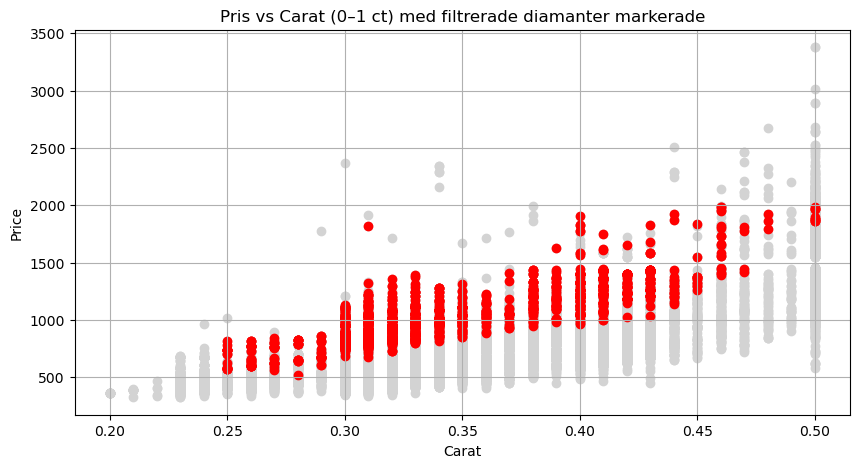

In [119]:
# Filtrera alla diamanter till endast de med carat mellan 0 och 0.5
df_under_05carat = df[df["carat"] <= 0.5]

# Filtrera matchande diamanter inom 0.25–0.5 carat, med specifika villkor
filtered = df_under_05carat[
    (df_under_05carat["carat"] >= 0.25) & (df_under_05carat["carat"] <= 0.5) &
    (df_under_05carat["clarity"].isin(["IF", "VVS1"])) &
    (df_under_05carat["color"].isin(["E", "F", "G"])) &
    (df_under_05carat["cut"] == 'Excellent') &
    (df_under_05carat["price"] < 2000)
]

print("Antal matchande diamanter:", len(filtered))

# Rita scatterplot med alla diamanter under 0.5 carat i grått
plt.figure(figsize=(10, 5))
plt.scatter(df_under_05carat["carat"], df_under_05carat["price"], color="lightgray", label="Alla diamanter <0.5 ct")


plt.scatter(filtered["carat"], filtered["price"], color="red", label="Matchande diamanter")


plt.xlabel("Carat")
plt.ylabel("Price")
plt.title("Pris vs Carat (0–1 ct) med filtrerade diamanter markerade")
plt.grid(True)
plt.show()

**Vad vi ser:**

Från denna scatterplot ser vi att diamanterna i intervallet mellan 0.20 och 0.50 carat är relativt koncentrerade i pris, men att det samtidigt finns stenar som uppfyller våra kvalitetskriterier och som kan köpas till ett lägre pris. Exempelvis kan vi under 0.28 carat identifiera en diamant som är billigare än övriga i samma kategori.

**Detta innebär följande:**

Prisvolatiliteten ökar tydligt redan vid 0.30 till 0.40 carat. Genom att beräkna medianpriset för varje caratintervall kan vi filtrera ut de stenar som ligger under medianen och därmed identifiera potentiella köplägen med högre sannolikhet för avkastning. Det tyder på att rätt köpbeslut inom detta spann kan vara särskilt lönsamt.

**Ur ett affärsperspektiv:**

Från affärsperspektiv ser vi att störst potential finns i intervallet mellan 0.30 och 0.40 carat. Här finns flest stenar och volatiliteten i pris är högst, vilket innebär större möjligheter att göra fynd. Däremot är chanserna till lönsam affär lägre i t.ex. 0.47-caratintervallet eftersom antalet tillgängliga stenar är färre. Vi väljer därför att sortera bort dessa ur analysen för att fokusera på de intervall där utbudet och möjligheterna till vinst är som störst.

### 3.15 Beräkna medianpris för diamanter inom caratintervaller

In [117]:
bins = np.arange(0.3, 0.41, 0.01)  
labels = [f"{round(bins[i], 2)}–{round(bins[i+1], 2)}" for i in range(len(bins) - 1)]

# Skapa ny kolumn med intervallbaserade caratgrupper
filtered["carat_interval"] = pd.cut(filtered["carat"], bins=bins, labels=labels, include_lowest=True)

# Räkna medianpris för varje intervall
median_prices = filtered.groupby("carat_interval")["price"].median().reset_index()

# Visa resultatet
print(median_prices)

  carat_interval   price
0       0.3–0.31   886.0
1      0.31–0.32   926.0
2      0.32–0.33   984.0
3      0.33–0.34   999.5
4      0.34–0.35  1041.0
5      0.35–0.36  1059.5
6      0.36–0.37  1056.0
7      0.37–0.38  1200.0
8      0.38–0.39  1183.0
9       0.39–0.4  1234.0


/var/folders/66/n7t02x9n3px6n956yn182btr0000gn/T/ipykernel_15541/3855951659.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered["carat_interval"] = pd.cut(filtered["carat"], bins=bins, labels=labels, include_lowest=True)
/var/folders/66/n7t02x9n3px6n956yn182btr0000gn/T/ipykernel_15541/3855951659.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_prices = filtered.groupby("carat_interval")["price"].median().reset_index()


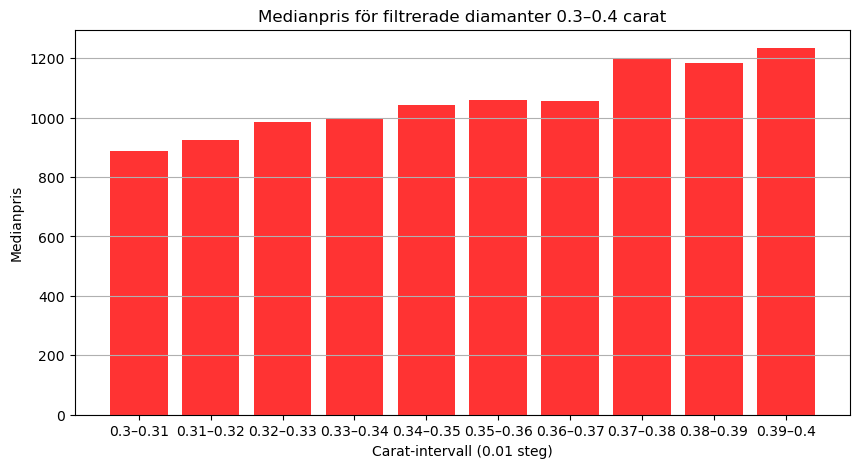

In [71]:
plt.figure(figsize=(10, 5))
plt.bar(median_prices["carat_interval"], median_prices["price"], color="red", alpha=0.8)
plt.xlabel("Carat-intervall (0.01 steg)")
plt.ylabel("Medianpris")
plt.title("Medianpris för filtrerade diamanter 0.3–0.4 carat")
plt.grid(axis='y')
plt.show()

Ovan ser vi medianpris för caratintervall

### 3.16 Filtrera på diamanter vars pris är 10% under medianpriset

In [115]:
median_dict = median_prices.set_index("carat_interval")["price"].to_dict()

#10% under medianen för sitt itnervall
below_median_10 = []

for idx, row in filtered.iterrows():
    interval = row["carat_interval"]
    price = row["price"]
    
    if pd.isna(interval) or interval not in median_dict:
        continue
    
    median = median_dict[interval]
    if price < median * 0.90:
        below_median_10.append({
            "index": idx,
            "carat": row["carat"],
            "price": price,
            "interval": interval,
            "median": median,
            "threshold_90pct": median * 0.90
        })


df_below_median_10 = pd.DataFrame(below_median_10)
print(df_below_median_10)

     index  carat   price  interval  median  threshold_90pct
0    28657   0.31   676.0  0.3–0.31   886.0            797.4
1    28885   0.30   684.0  0.3–0.31   886.0            797.4
2    29832   0.31   710.0  0.3–0.31   886.0            797.4
3    30061   0.30   720.0  0.3–0.31   886.0            797.4
4    30260   0.31   725.0  0.3–0.31   886.0            797.4
..     ...    ...     ...       ...     ...              ...
243  39812   0.40  1097.0  0.39–0.4  1234.0           1110.6
244  39813   0.40  1097.0  0.39–0.4  1234.0           1110.6
245  39814   0.40  1097.0  0.39–0.4  1234.0           1110.6
246  39815   0.40  1097.0  0.39–0.4  1234.0           1110.6
247  39816   0.40  1097.0  0.39–0.4  1234.0           1110.6

[248 rows x 6 columns]


**Vad vi ser:**

Från denna lista ser vi totalt 248 diamanter som uppfyller kriterierna för både rätt caratintervall och de kvalitetsattribut som är mest relevanta för en nordisk köpare. Det handlar om stenar som ger mest diamant för pengarna, budgetvänliga alternativ utan att kompromissa med utseende eller upplevd kvalitet.

**Detta innebär följande:**

Dessa diamanter har hög potential för avkastning eftersom vi, baserat på medianvärden, bör kunna sälja dem för minst medianpriset eller högre. Det innebär att affären blir lönsam för Guldfynd, vilket är det övergripande målet.

**Ur ett affärsperspektiv:**

Från affärsperspektiv ser vi att filtreringen inte bara fokuserar på pris utan också på preferenserna hos den nordiska målgruppen. Detta ökar sannolikheten att dessa stenar inte bara köps in till rätt pris, utan också snabbt hittar köpare. Det höga antalet potentiella kunder för just denna typ av sten innebär att omsättningshastigheten också kan bli hög vilket gör dessa 248 stenar särskilt attraktiva ur ett kommersiellt perspektiv.

### 3.17 Beräkning av potentiell avkastning

In [113]:
# Säkerställ rätt typ
df_below_median_10["price"] = df_below_median_10["price"].astype(float)
df_below_median_10["median"] = df_below_median_10["median"].astype(float)

# Summera
total_price = df_below_median_10["price"].sum()
total_median = df_below_median_10["median"].sum()
difference = total_price - total_median

# Skriv ut
print(f"Antal stenar: {len(df_below_median_10)}")
print(f"Total faktisk pris: {total_price:,.2f}")
print(f"Total medianpris: {total_median:,.2f}")
print(f"Differens: {difference:,.2f}")

Antal stenar: 248
Total faktisk pris: 209,440.00
Total medianpris: 242,475.50
Differens: -33,035.50


## 4. Executive summary

Vi har genomfört en datadriven analys för att identifiera diamanter med hög kvalitet till ett attraktivt inköpspris. Analysen fokuserar på diamanter inom viktintervallet 0.3 till 0.4 carat och bygger på följande urvalskriterier:

Kriterier:

- Carat: 0.3 – 0.4

- Clarity: IF eller VVS1 (Internally Flawless eller Very Very Slightly Included)

- Color: E, F eller G (färgskala med hög färgkvalitet)

- Cut: Excellent

Anledning till kriterierna är att de matchar de nordiska preferenserna, de finns en större volym av stenar i detta segment och en större efterfrågan.

För att säkerställa god marginal och attraktiva återförsäljningsmöjligheter fokuserar vi endast på de diamanter som:

- Matchar ovanstående kvalitetskriterier

- Har ett inköpspris som är minst 10 % under medianpriset i sitt respektive caratintervall

Totalt uppfyller 248 diamanter dessa kriterier.

Investera i samtliga stenar för 10% under medianpris:
- $209,440.00

Potentiellt försäljningspris baserat på medianen för samtliga stenar:
- $242,475.50

Potentiell vinst:
- $33,035.50

Procentuell avkastning:
- ca 15.78 %

Notera att det finns goda möjligheter till att sälja diamanterna för dyrare än medianpriset!


## 5. Funktion för sökning av underprissatta diamanter

In [111]:
def find_underpriced_diamonds(df):

    df_under_05_carat = df[df["carat"] <= 0.5]

    # kvalitetskrav
    filtered = df_under_05_carat[
        (df_under_05_carat["carat"] >= 0.25) & (df_under_05_carat["carat"] <= 0.5) &
        (df_under_05_carat['clarity'].isin(["IF", "VVS1"])) &
        (df_under_05_carat['color'].isin(["E", "F", "G"])) &
        (df_under_05_carat['cut'] == 'Excellent') &
        (df_under_05_carat['price'] < 3000)
    ]


    bins = np.arange(0.3, 0.41, 0.01)
    labels = [f"{round(bins[i], 2)}–{round(bins[i+1], 2)}" for i in range(len(bins) - 1)]
    filtered["carat_interval"] = pd.cut(filtered["carat"], bins=bins, labels=labels, include_lowest=True)


    median_prices = filtered.groupby("carat_interval")["price"].median().reset_index()
    median_dict = median_prices.set_index("carat_interval")["price"].to_dict()

    # 10% under medianpris
    below_median_10 = []
    for idx, row in filtered.iterrows():
        interval = row["carat_interval"]
        price = row["price"]
        if pd.isna(interval) or interval not in median_dict:
            continue
        median = median_dict[interval]
        if price < median * 0.90:
            below_median_10.append({
                "index": idx,
                "carat": row["carat"],
                "price": float(price),
                "interval": interval,
                "median": float(median),
                "buy for:": float(median * 0.90)
            })

    df_below_median_10 = pd.DataFrame(below_median_10)

    # beräkna och förberedd data för beräkning av potentiell vinst
    total_price = df_below_median_10["price"].sum()
    total_median = df_below_median_10["median"].sum()
    difference = total_median - total_price

    # Summera
    print(f"Antal stenar: {len(df_below_median_10)}")
    print(f"Total faktisk pris: {total_price:,.2f}")
    print(f"Total medianpris: {total_median:,.2f}")
    print(f"Potentiell vinst: {difference:,.2f}")
    print("\nAlla matchande diamanter:\n")
    print(df_below_median_10.to_string(index=False))

    return df_below_median_10

result = find_underpriced_diamonds(df)
print(result)

Antal stenar: 248
Total faktisk pris: 209,440.00
Total medianpris: 242,475.50
Potentiell vinst: 33,035.50

Alla matchande diamanter:

 index  carat  price  interval  median  buy for:
 28657   0.31  676.0  0.3–0.31   886.0    797.40
 28885   0.30  684.0  0.3–0.31   886.0    797.40
 29832   0.31  710.0  0.3–0.31   886.0    797.40
 30061   0.30  720.0  0.3–0.31   886.0    797.40
 30260   0.31  725.0  0.3–0.31   886.0    797.40
 30433   0.32  730.0 0.31–0.32   926.0    833.40
 30460   0.32  732.0 0.31–0.32   926.0    833.40
 30521   0.32  733.0 0.31–0.32   926.0    833.40
 30531   0.30  734.0  0.3–0.31   886.0    797.40
 30635   0.30  735.0  0.3–0.31   886.0    797.40
 30636   0.30  735.0  0.3–0.31   886.0    797.40
 30701   0.30  737.0  0.3–0.31   886.0    797.40
 30705   0.30  737.0  0.3–0.31   886.0    797.40
 30810   0.31  743.0  0.3–0.31   886.0    797.40
 30994   0.30  747.0  0.3–0.31   886.0    797.40
 30995   0.30  747.0  0.3–0.31   886.0    797.40
 31017   0.31  749.0  0.3–0.31   

/var/folders/66/n7t02x9n3px6n956yn182btr0000gn/T/ipykernel_15541/331431746.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered["carat_interval"] = pd.cut(filtered["carat"], bins=bins, labels=labels, include_lowest=True)
/var/folders/66/n7t02x9n3px6n956yn182btr0000gn/T/ipykernel_15541/331431746.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_prices = filtered.groupby("carat_interval")["price"].median().reset_index()
